# MRNet Knee MRI Classification Demo

Transfer-learning classifier for the Stanford MRNet dataset: three binary tasks (abnormal, ACL tear, meniscal tear) using ResNet18 and multi-plane fusion.

## Dataset Setup — Stanford MRNet

The **MRNet dataset** is provided by the Stanford ML Group. It contains 1,370 knee MRI exams (1,130 train / 120 valid / 120 hidden test) across three planes: **axial**, **coronal**, and **sagittal**. Each exam has binary labels for three conditions: **abnormality**, **ACL tear**, and **meniscal tear**.

### How to download
1. Visit the MRNet competition page: `https://stanfordmlgroup.github.io/competitions/mrnet/`
2. Fill out the research-use agreement to receive a download link.
3. Download the `.zip` archive (~5.7 GB).

### Where to place the data
Extract the zip into the project's `data/` folder so the directory tree looks like this:


> **Note:** The zip often extracts with a double-nested `MRNet-v1.0/MRNet-v1.0/` structure. The configuration cell below auto-detects this, so just extract as-is — no renaming needed.

**Google Colab / Drive:** In the **configuration** cell, set `PROJECT_ROOT_OVERRIDE` and/or `DATA_ROOT_OVERRIDE` to your notebook or Drive paths so the resolver finds folders `train/` and `valid/`. Run **Configuration**, then the **imports** cell (defines `assert_config_ready`) before training.


In [11]:
import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch", "torchvision",
     "numpy", "pandas", "scikit-learn",
     "matplotlib", "tqdm"],
    capture_output=True, text=True,
)

CompletedProcess(args=['c:\\Users\\nickg\\dev\\CSULB\\CECS_553_Project\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'torch', 'torchvision', 'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'tqdm'], returncode=0, stdout='', stderr='')

## 1. Configuration

In [47]:
import random
from pathlib import Path
import numpy as np
import torch

# --- Optional path overrides (Google Colab / Drive / nonstandard tree) ---
# Leave as None to auto-detect. Example after mounting Drive on Colab:
#   PROJECT_ROOT_OVERRIDE = Path("/content/drive/MyDrive/CECS_553_Project")
#   DATA_ROOT_OVERRIDE = Path("/content/drive/MyDrive/mrnet/MRNet-v1.0/MRNet-v1.0")
PROJECT_ROOT_OVERRIDE = None
DATA_ROOT_OVERRIDE = None


def _resolve_mrnet_data_root(project_root, override):
    # Return a directory containing both train/ and valid/.
    candidates = []
    if override is not None:
        p = Path(override).resolve()
        candidates.extend(
            [
                p,
                p / "MRNet-v1.0" / "MRNet-v1.0",
                p / "MRNet-v1.0",
                p / "data" / "mrnetkneemris" / "MRNet-v1.0" / "MRNet-v1.0",
                p / "data" / "mrnetkneemris" / "MRNet-v1.0",
            ]
        )
    base = project_root / "data" / "mrnetkneemris"
    candidates.extend(
        [
            base / "MRNet-v1.0" / "MRNet-v1.0",
            base / "MRNet-v1.0",
            base,
        ]
    )
    seen = set()
    for c in candidates:
        try:
            c = c.resolve()
        except OSError:
            continue
        key = str(c)
        if key in seen:
            continue
        seen.add(key)
        if (c / "train").is_dir() and (c / "valid").is_dir():
            return c
    raise FileNotFoundError(
        "Could not find MRNet data: need a folder with both train/ and valid/.\n"
        "Edit DATA_ROOT_OVERRIDE in this cell to point to that folder (e.g. .../MRNet-v1.0/MRNet-v1.0).\n"
        f"PROJECT_ROOT was: {project_root.resolve()}"
    )


if PROJECT_ROOT_OVERRIDE is not None:
    PROJECT_ROOT = Path(PROJECT_ROOT_OVERRIDE).resolve()
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "notebooks").exists() and (PROJECT_ROOT.parent / "notebooks").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = _resolve_mrnet_data_root(PROJECT_ROOT, DATA_ROOT_OVERRIDE)

assert (DATA_ROOT / "train").is_dir(), "Missing train/ — check DATA_ROOT_OVERRIDE and MRNet extraction."
assert (DATA_ROOT / "valid").is_dir(), "Missing valid/ — check DATA_ROOT_OVERRIDE and MRNet extraction."

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 553
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Constants
TASKS  = ("abnormal", "acl", "meniscus")
PLANES = ("axial", "coronal", "sagittal")
TASK   = "abnormal"

# Hyperparameters
INPUT_SIZE           = 224
BATCH_SIZE           = 1
LR                   = 1e-4
WEIGHT_DECAY         = 0.0
EPOCHS               = 20
FREEZE_BACKBONE_EPOCHS = 1
NUM_SLICE_SAMPLE     = None

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_ROOT:    {DATA_ROOT}")
print(f"Device:       {'cuda' if torch.cuda.is_available() else 'cpu'}")


DATA_ROOT: C:\Users\nickg\dev\CSULB\CECS_553_Project\data\mrnetkneemris\MRNet-v1.0\MRNet-v1.0
Device:    cuda


In [13]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms.functional as F

from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# --- Path helpers (out-of-order runs / Colab): call before training or saving figures ---
def assert_config_ready():
    """Raise with a clear message if the configuration cell was not run."""
    need = ("PROJECT_ROOT", "DATA_ROOT", "CHECKPOINT_DIR", "TASKS", "PLANES", "EPOCHS", "LR")
    bad = [n for n in need if n not in globals()]
    if bad:
        raise RuntimeError(
            "Run the configuration cell first (section '1. Configuration'). "
            "Missing: " + ", ".join(bad)
        )
    if not (DATA_ROOT / "train").is_dir() or not (DATA_ROOT / "valid").is_dir():
        raise RuntimeError(
            f"DATA_ROOT is invalid ({DATA_ROOT}). Re-run the configuration cell "
            "or set DATA_ROOT_OVERRIDE to the MRNet folder with train/ and valid/."
        )


def ensure_checkpoint_dir():
    """Define CHECKPOINT_DIR if the config cell was skipped."""
    root = globals().get("PROJECT_ROOT")
    if root is None:
        root = Path.cwd().resolve()
        if not (root / "notebooks").exists() and (root.parent / "notebooks").exists():
            root = root.parent
        globals()["PROJECT_ROOT"] = root
    ck = root / "checkpoints"
    ck.mkdir(parents=True, exist_ok=True)
    globals()["CHECKPOINT_DIR"] = ck
    return ck


def ensure_report_fig_dir():
    """Define REPORT_FIG_DIR if the config cell was skipped."""
    root = globals().get("PROJECT_ROOT")
    if root is None:
        root = Path.cwd().resolve()
        if not (root / "notebooks").exists() and (root.parent / "notebooks").exists():
            root = root.parent
        globals()["PROJECT_ROOT"] = root
    d = root / "reports" / "figures"
    d.mkdir(parents=True, exist_ok=True)
    globals()["REPORT_FIG_DIR"] = d
    return d



## 2. Data: Load labels and define dataset

`load_labels` merges the three CSV files per split. `MRNetDataset` loads axial/coronal/sagittal `.npy` volumes per case and returns tensors plus the label for the chosen task.

In [53]:
def load_labels(data_root, split):
    """Load and merge CSV labels for a split (train or valid)."""
    data_root = Path(data_root)
    abnormal = pd.read_csv(
        data_root / f"{split}-abnormal.csv",
        header=None,
        names=["case", "abnormal"],
        dtype={"case": str, "abnormal": np.int64},
    )
    acl = pd.read_csv(
        data_root / f"{split}-acl.csv",
        header=None,
        names=["case", "acl"],
        dtype={"case": str, "acl": np.int64},
    )
    meniscus = pd.read_csv(
        data_root / f"{split}-meniscus.csv",
        header=None,
        names=["case", "meniscus"],
        dtype={"case": str, "meniscus": np.int64},
    )
    return abnormal.merge(acl, on="case").merge(meniscus, on="case")

In [54]:
class MRNetDataset(Dataset):
    """Dataset that returns (axial, coronal, sagittal) volumes and one task label."""

    def __init__(self, data_root, split, task, input_size=224, num_slice_sample=None, augment=False):
        assert split in ("train", "valid") and task in TASKS
        self.data_root = Path(data_root)
        self.split = split
        self.task = task
        self.input_size = input_size
        self.num_slice_sample = num_slice_sample
        self.augment = augment
        self.labels_df = load_labels(data_root, split)
        self.cases = self.labels_df["case"].tolist()
        self.label_col = task

    def __len__(self):
        return len(self.cases)

    def _load_plane(self, case, plane):
        path = self.data_root / self.split / plane / f"{case}.npy"
        arr = np.load(path)
        return arr.astype(np.float32)

    def _preprocess(self, arr):
        n, h, w = arr.shape
        mi, ma = arr.min(), arr.max()
        if ma > mi:
            arr = (arr - mi) / (ma - mi)
        if self.num_slice_sample is not None and n > self.num_slice_sample:
            idx = np.random.choice(n, self.num_slice_sample, replace=False)
            idx.sort()
            arr = arr[idx]
            n = self.num_slice_sample
        if h != self.input_size or w != self.input_size:
            t = torch.from_numpy(arr).unsqueeze(1)
            t = F.resize(t, [self.input_size, self.input_size])
            arr = t.numpy()
        else:
            arr = arr[:, np.newaxis, :, :]
        arr = np.repeat(arr, 3, axis=1)
        if self.augment and self.split == "train" and np.random.rand() > 0.5:
            arr = np.flip(arr, axis=-1).copy()
        return torch.from_numpy(arr).float()

    def __getitem__(self, idx):
        case = self.cases[idx]
        axial = self._preprocess(self._load_plane(case, "axial"))
        coronal = self._preprocess(self._load_plane(case, "coronal"))
        sagittal = self._preprocess(self._load_plane(case, "sagittal"))
        label = self.labels_df.iloc[idx][self.label_col]
        return {
            "axial": axial, "coronal": coronal, "sagittal": sagittal,
            "label": torch.tensor(label, dtype=torch.float32),
            "case": case,
        }


def collate_mrnet(batch):
    return {
        "axial": batch[0]["axial"],
        "coronal": batch[0]["coronal"],
        "sagittal": batch[0]["sagittal"],
        "label": torch.stack([b["label"] for b in batch]),
        "case": [b["case"] for b in batch],
    }

### 2a. Explore the data

Preview labels, class balance, raw volume shapes, and sample MRI slices before training.

In [16]:
# --- Label overview ---
train_labels = load_labels(DATA_ROOT, "train")
valid_labels = load_labels(DATA_ROOT, "valid")

print(f"Train samples: {len(train_labels)}  |  Valid samples: {len(valid_labels)}")
print(f"\nFirst 5 rows (train):")
display(train_labels.head())

print("\nLabel distribution (train):")
for task in TASKS:
    pos = int(train_labels[task].sum())
    neg = len(train_labels) - pos
    print(f"  {task:>10s}: {pos} positive / {neg} negative  ({100 * pos / len(train_labels):.1f}% pos)")

print("\nLabel distribution (valid):")
for task in TASKS:
    pos = int(valid_labels[task].sum())
    neg = len(valid_labels) - pos
    print(f"  {task:>10s}: {pos} positive / {neg} negative  ({100 * pos / len(valid_labels):.1f}% pos)")

Train samples: 1130  |  Valid samples: 120

First 5 rows (train):


,case,abnormal,acl,meniscus
0,0000,1,0,0
1,0001,1,1,1
2,0002,1,0,0
3,0003,1,0,1
4,0004,1,0,0



Label distribution (train):
    abnormal: 913 positive / 217 negative  (80.8% pos)
         acl: 208 positive / 922 negative  (18.4% pos)
    meniscus: 397 positive / 733 negative  (35.1% pos)

Label distribution (valid):
    abnormal: 95 positive / 25 negative  (79.2% pos)
         acl: 54 positive / 66 negative  (45.0% pos)
    meniscus: 52 positive / 68 negative  (43.3% pos)


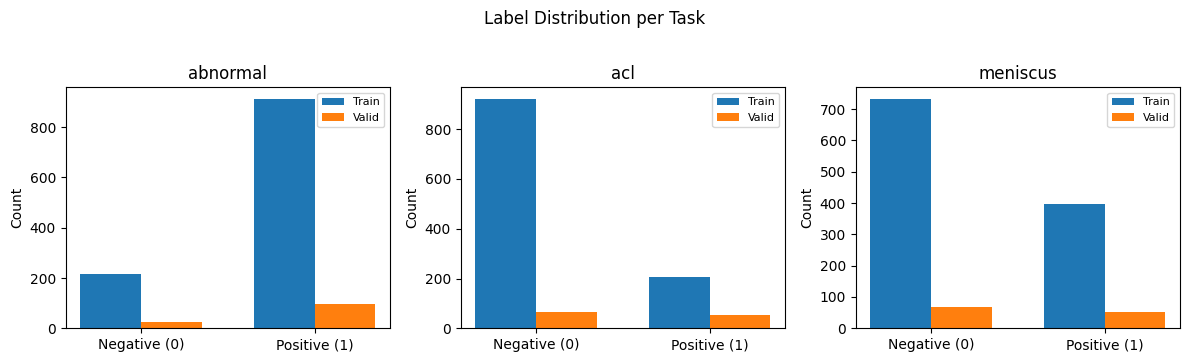

In [17]:
# --- Label balance bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, task in zip(axes, TASKS):
    pos_train = int(train_labels[task].sum())
    neg_train = len(train_labels) - pos_train
    pos_valid = int(valid_labels[task].sum())
    neg_valid = len(valid_labels) - pos_valid

    x = np.arange(2)
    w = 0.35
    ax.bar(x - w / 2, [neg_train, pos_train], width=w, label="Train")
    ax.bar(x + w / 2, [neg_valid, pos_valid], width=w, label="Valid")
    ax.set_xticks(x)
    ax.set_xticklabels(["Negative (0)", "Positive (1)"])
    ax.set_title(task)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Label Distribution per Task", y=1.02)
fig.tight_layout()
plt.show()

In [18]:
# --- Raw volume shapes for a sample case ---
sample_case = train_labels["case"].iloc[0]
print(f"Sample case: {sample_case}")
print(f"Labels: abnormal={train_labels.iloc[0]['abnormal']}, acl={train_labels.iloc[0]['acl']}, meniscus={train_labels.iloc[0]['meniscus']}")
print()

for plane in PLANES:
    vol = np.load(DATA_ROOT / "train" / plane / f"{sample_case}.npy")
    print(f"  {plane:>10s}: shape={vol.shape}, dtype={vol.dtype}, min={vol.min():.2f}, max={vol.max():.2f}")

Sample case: 0000
Labels: abnormal=1, acl=0, meniscus=0

       axial: shape=(44, 256, 256), dtype=uint8, min=0.00, max=255.00
     coronal: shape=(36, 256, 256), dtype=uint8, min=0.00, max=255.00
    sagittal: shape=(36, 256, 256), dtype=uint8, min=0.00, max=255.00


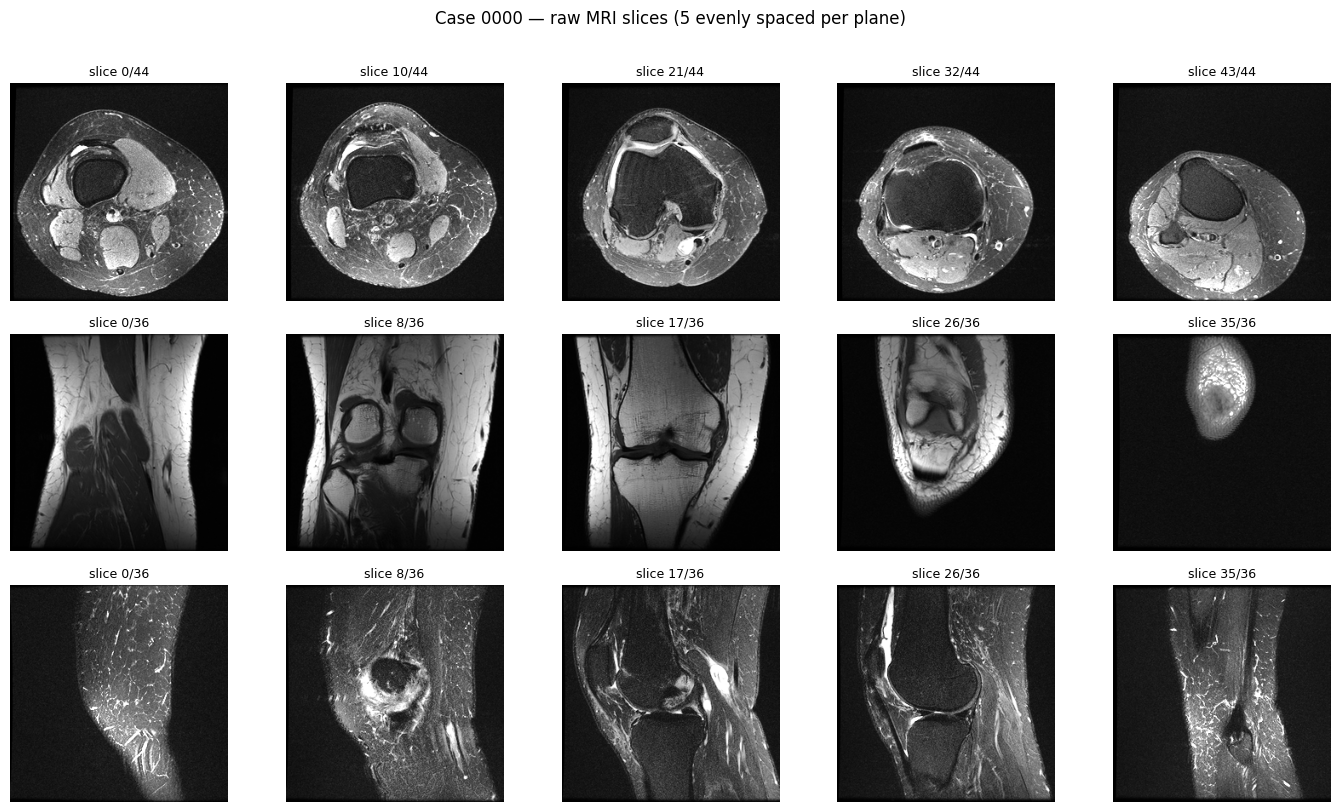

In [19]:
# --- Visualize sample MRI slices (one case, all 3 planes) ---
fig, axes = plt.subplots(3, 5, figsize=(14, 8))

for row, plane in enumerate(PLANES):
    vol = np.load(DATA_ROOT / "train" / plane / f"{sample_case}.npy").astype(np.float32)
    n_slices = vol.shape[0]
    indices = np.linspace(0, n_slices - 1, 5, dtype=int)
    for col, idx in enumerate(indices):
        axes[row, col].imshow(vol[idx], cmap="gray")
        axes[row, col].set_title(f"slice {idx}/{n_slices}", fontsize=9)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(plane, fontsize=12, rotation=0, labelpad=60, va="center")

fig.suptitle(f"Case {sample_case} — raw MRI slices (5 evenly spaced per plane)", y=1.01)
fig.tight_layout()
plt.show()

In [10]:
# --- Preprocessed tensor shapes (what the model actually sees) ---
demo_ds = MRNetDataset(DATA_ROOT, "train", TASK, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False)
sample = demo_ds[0]

print(f"Case: {sample['case']}")
print(f"Label ({TASK}): {int(sample['label'].item())}")
print()
for plane in PLANES:
    t = sample[plane]
    print(f"  {plane:>10s}: tensor shape={tuple(t.shape)}, min={t.min():.3f}, max={t.max():.3f}")

print(f"\nEach plane tensor is (num_slices, 3, {INPUT_SIZE}, {INPUT_SIZE}) — ready for ResNet18.")

Case: 0000
Label (abnormal): 1

       axial: tensor shape=(44, 3, 224, 224), min=0.000, max=1.000
     coronal: tensor shape=(36, 3, 224, 224), min=0.000, max=1.000
    sagittal: tensor shape=(36, 3, 224, 224), min=0.000, max=1.000

Each plane tensor is (num_slices, 3, 224, 224) — ready for ResNet18.


## 3. Model

ResNet18 backbone per plane; max-pool over slices; concatenate the three planes; linear head to one logit per task.

In [21]:
def _get_backbone(pretrained=True):
    """ResNet18 without the final classifier; outputs 512-d per image."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    net = models.resnet18(weights=weights)
    net.fc = nn.Identity()
    return net


class MRNetBackbone(nn.Module):
    """Single-plane backbone: N slices -> N x 512 -> pool -> 512."""

    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = _get_backbone(pretrained=pretrained)

    def forward(self, x):
        return self.backbone(x)


class MRNet(nn.Module):
    def __init__(self, task, pretrained=True, dropout=0.0):
        super().__init__()
        self.task = task
        self.axial_backbone = MRNetBackbone(pretrained=pretrained)
        self.coronal_backbone = MRNetBackbone(pretrained=pretrained)
        self.sagittal_backbone = MRNetBackbone(pretrained=pretrained)
        self.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(3 * 512, 1))

    def _plane_forward(self, backbone, volume):
        feat = backbone(volume)
        return feat.max(dim=0, keepdim=True)[0]

    def forward(self, axial, coronal, sagittal):
        v_ax = self._plane_forward(self.axial_backbone, axial)
        v_co = self._plane_forward(self.coronal_backbone, coronal)
        v_sag = self._plane_forward(self.sagittal_backbone, sagittal)
        fused = torch.cat([v_ax, v_co, v_sag], dim=1)
        return self.fc(fused).squeeze(-1)

    def freeze_backbone(self):
        for backbone in (self.axial_backbone, self.coronal_backbone, self.sagittal_backbone):
            for p in backbone.parameters():
                p.requires_grad = False

    def unfreeze_backbone(self):
        for backbone in (self.axial_backbone, self.coronal_backbone, self.sagittal_backbone):
            for p in backbone.parameters():
                p.requires_grad = True

## 4. Training and Validation Functions

In [22]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="Train", leave=False):
        axial = batch["axial"].to(device)
        coronal = batch["coronal"].to(device)
        sagittal = batch["sagittal"].to(device)
        label = batch["label"].to(device)
        optimizer.zero_grad()
        logit = model(axial=axial, coronal=coronal, sagittal=sagittal)
        loss = criterion(logit, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    crit = nn.BCEWithLogitsLoss()
    logits_list, labels_list = [], []
    for batch in tqdm(loader, desc="Valid", leave=False):
        axial = batch["axial"].to(device)
        coronal = batch["coronal"].to(device)
        sagittal = batch["sagittal"].to(device)
        logit = model(axial=axial, coronal=coronal, sagittal=sagittal)
        logits_list.append(logit.cpu())
        labels_list.append(batch["label"].float().cpu())
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    valid_bce = crit(logits, labels).item()
    probs = torch.sigmoid(logits).numpy()
    labels_np = labels.numpy()
    if labels_np.sum() == 0 or labels_np.sum() == len(labels_np):
        return 0.5, valid_bce
    return roc_auc_score(labels_np, probs), valid_bce


@torch.no_grad()
def collect_val_probs(model, loader, device):
    """Full validation set labels and predicted probabilities (for ROC curves)."""
    model.eval()
    logits_list, labels_list = [], []
    for batch in tqdm(loader, desc="Valid", leave=False):
        axial = batch["axial"].to(device)
        coronal = batch["coronal"].to(device)
        sagittal = batch["sagittal"].to(device)
        logit = model(axial=axial, coronal=coronal, sagittal=sagittal)
        logits_list.append(logit.cpu())
        labels_list.append(batch["label"].float().cpu())
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    probs = torch.sigmoid(logits).numpy().ravel()
    return labels.numpy().ravel(), probs

## 5. Fine-tune all three tasks (frozen backbone, then unfreeze)

Trains one model per task with `FREEZE_BACKBONE_EPOCHS` (see config). Saves `mrnet_{task}_best.pt` and `section5_training_history.json`.


In [26]:
import json

assert_config_ready()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}
task_histories = {}
run_start = time.time()
SECTION5_METRICS_FILE = CHECKPOINT_DIR / "section5_training_history.json"

print(f"Starting 3-task run on device='{device}'")
print(f"Settings: epochs={EPOCHS}, lr={LR}, batch_size={BATCH_SIZE}, num_slice_sample={NUM_SLICE_SAMPLE}")

for task in TASKS:
    print(f"\n--- Training task: {task} ---")
    train_ds = MRNetDataset(DATA_ROOT, "train", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=True)
    valid_ds = MRNetDataset(DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_mrnet)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_mrnet)

    model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    model.freeze_backbone()
    best_auc = 0.0
    hist = {
        "train_loss": [],
        "valid_auc": [],
        "valid_bce": [],
        "best_auc": 0.0,
        "best_epoch": -1,
    }

    for epoch in range(EPOCHS):
        if epoch == FREEZE_BACKBONE_EPOCHS:
            model.unfreeze_backbone()
            optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        tr_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        _v = validate(model, valid_loader, device)
        va_auc, va_bce = (_v[0], _v[1]) if isinstance(_v, tuple) else (_v, None)
        hist["train_loss"].append(float(tr_loss))
        hist["valid_auc"].append(float(va_auc))
        hist["valid_bce"].append(None if va_bce is None else float(va_bce))
        if (epoch + 1) % 5 == 0 or epoch == 0:
            _vb = f"{va_bce:.4f}" if va_bce is not None else "n/a"
            print(
                f"  Epoch {epoch + 1:02d}/{EPOCHS:02d} | "
                f"train_loss={tr_loss:.4f} | valid_auc={va_auc:.4f} | valid_bce={_vb}"
            )
        if va_auc > best_auc:
            best_auc = va_auc
            hist["best_auc"] = float(va_auc)
            hist["best_epoch"] = epoch + 1
            _ckpt = {"epoch": epoch, "model": model.state_dict(), "auc": float(va_auc)}
            if va_bce is not None:
                _ckpt["valid_bce"] = float(va_bce)
            torch.save(_ckpt, CHECKPOINT_DIR / f"mrnet_{task}_best.pt")

    results[task] = best_auc
    task_histories[task] = hist
    print(f"  Best AUC for {task}: {best_auc:.4f}")

print("\n=== Summary ===")
for task in TASKS:
    print(f"  {task}: {results[task]:.4f}")
mean_auc = sum(results.values()) / len(TASKS)
print(f"  Average AUC (competition metric): {mean_auc:.4f}")
print(f"  Elapsed time: {(time.time() - run_start) / 60:.1f} minutes")

section5_record = {
    "training_mode": "fine_tune",
    "config": {
        "EPOCHS": EPOCHS,
        "LR": LR,
        "BATCH_SIZE": BATCH_SIZE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "NUM_SLICE_SAMPLE": NUM_SLICE_SAMPLE,
        "FREEZE_BACKBONE_EPOCHS": FREEZE_BACKBONE_EPOCHS,
        "INPUT_SIZE": INPUT_SIZE,
        "SEED": SEED,
    },
    "summary": {
        "per_task_auc": {k: float(v) for k, v in results.items()},
        "mean_auc": float(mean_auc),
        "elapsed_minutes": (time.time() - run_start) / 60.0,
    },
    "task_histories": task_histories,
}
with open(SECTION5_METRICS_FILE, "w", encoding="utf-8") as f:
    json.dump(section5_record, f, indent=2)
print(f"\nSaved per-epoch metrics to {SECTION5_METRICS_FILE}")

Starting 3-task run on device='cuda'
Settings: epochs=20, lr=0.0001, batch_size=1, num_slice_sample=None

--- Training task: abnormal ---


  Epoch 01/20 | train_loss=0.5395 | valid_auc=0.5789 | valid_bce=n/a


  Epoch 05/20 | train_loss=0.3672 | valid_auc=0.7781 | valid_bce=n/a


  Epoch 10/20 | train_loss=0.2322 | valid_auc=0.7735 | valid_bce=n/a


  Epoch 15/20 | train_loss=0.0758 | valid_auc=0.8198 | valid_bce=n/a


...

  Epoch 01/20 | train_loss=0.6945 | valid_auc=0.4720 | valid_bce=n/a


  Epoch 05/20 | train_loss=0.5511 | valid_auc=0.7305 | valid_bce=n/a


  Epoch 10/20 | train_loss=0.2520 | valid_auc=0.7189 | valid_bce=n/a


  Epoch 15/20 | train_loss=0.0869 | valid_auc=0.7763 | valid_bce=n/a


  Epoch 20/20 | train_loss=0.0845 | valid_auc=0.7169 | valid_bce=n/a
  Best AUC for meniscus: 0.7794

=== Summary ===
  abnormal: 0.8699
  acl: 0.9329
  meniscus: 0.7794
  Average AUC (competition metric): 0.8607
  Elapsed time: 353.7 minutes

Saved per-epoch metrics to C:\Users\nickg\dev\CSULB\CECS_553_Project\checkpoints\section5_training_history.json


### 5a. Fine-tuning — load metrics & training curves

Run the **load** cell, then the **plot** cell. Data: in-memory `task_histories` or `section5_training_history.json`.


In [45]:
import json

_section5_path = CHECKPOINT_DIR / "section5_training_history.json"
if "task_histories" in dir() and task_histories and len(task_histories) == len(TASKS):
    print(f"Using task_histories from memory ({len(task_histories)} tasks)")
elif _section5_path.exists():
    with open(_section5_path, encoding="utf-8") as f:
        _sec5 = json.load(f)
    task_histories = _sec5["task_histories"]
    print(f"Loaded task_histories from {_section5_path.name}")
else:
    task_histories = {}
    print(f"No metrics yet — run fine-tuning training above or create {_section5_path.name}")

Using task_histories from memory (3 tasks)


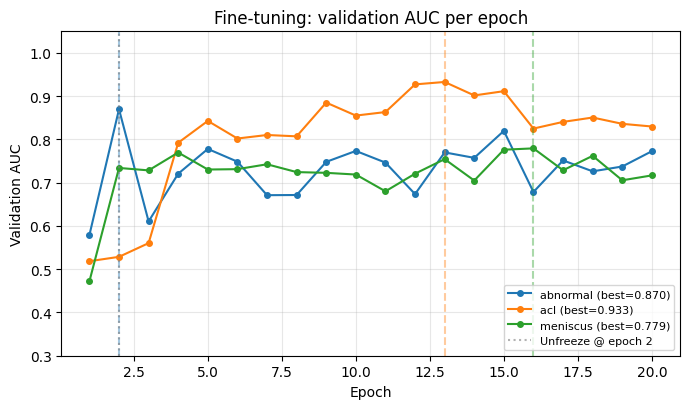

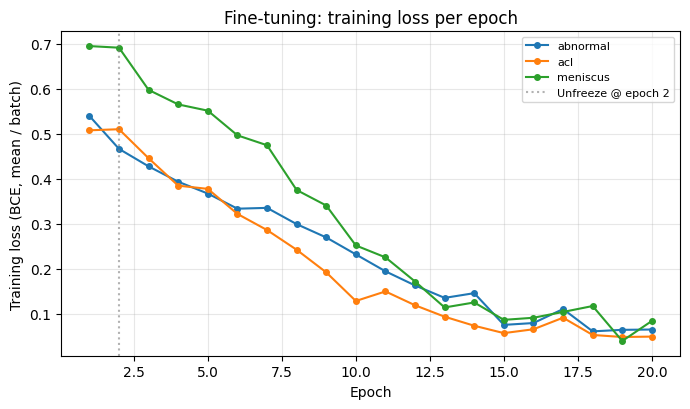

Skipping validation BCE: no per-epoch BCE in history (re-run Section 4 then 5), or set SHOW_VALID_BCE = False.


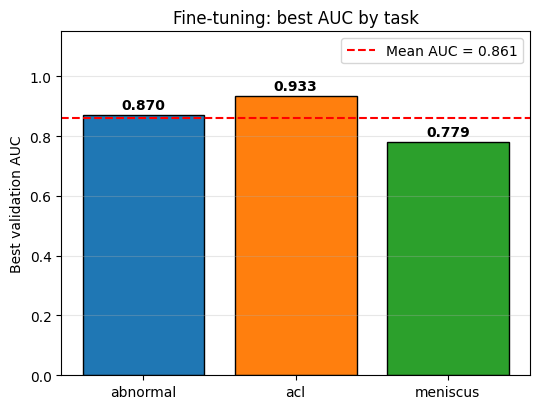


Per-task best AUC:
    abnormal: 0.8699  (epoch 2)
         acl: 0.9329  (epoch 13)
    meniscus: 0.7794  (epoch 16)
     Average: 0.8607


In [48]:
if not task_histories:
    print("Nothing to plot — load the fine-tuning metrics cells above after training or if the JSON exists.")
else:
    ensure_report_fig_dir()
    # Toggle which figures to display (one independent output per True)
    SHOW_VALID_AUC = True
    SHOW_TRAIN_LOSS = True
    SHOW_VALID_BCE = True
    SHOW_BEST_AUC_BARS = True
    SAVE_REPORT_FIGURES = True  # set False to skip writing PNGs to reports/figures/

    colors = {"abnormal": "#1f77b4", "acl": "#ff7f0e", "meniscus": "#2ca02c"}
    _h0 = next(iter(task_histories.values()))
    _nep = len(_h0["valid_auc"])
    has_vbce = all(
        h.get("valid_bce") and h["valid_bce"] and h["valid_bce"][0] is not None
        for h in task_histories.values()
    )

    if SHOW_VALID_AUC:
        fig, ax = plt.subplots(figsize=(7, 4.2))
        for t, hist in task_histories.items():
            ep = np.arange(1, len(hist["valid_auc"]) + 1)
            ax.plot(
                ep,
                hist["valid_auc"],
                marker="o",
                markersize=4,
                label=f'{t} (best={hist["best_auc"]:.3f})',
                color=colors[t],
            )
            ax.axvline(x=hist["best_epoch"], color=colors[t], linestyle="--", alpha=0.4)
        if FREEZE_BACKBONE_EPOCHS < _nep:
            ax.axvline(
                x=FREEZE_BACKBONE_EPOCHS + 1,
                color="gray",
                linestyle=":",
                alpha=0.6,
                label=f"Unfreeze @ epoch {FREEZE_BACKBONE_EPOCHS + 1}",
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation AUC")
        ax.set_title("Fine-tuning: validation AUC per epoch")
        ax.legend(fontsize=8)
        ax.set_ylim(0.3, 1.05)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "ft_valid_auc.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    if SHOW_TRAIN_LOSS:
        fig, ax = plt.subplots(figsize=(7, 4.2))
        for t, hist in task_histories.items():
            ep = np.arange(1, len(hist["train_loss"]) + 1)
            ax.plot(ep, hist["train_loss"], marker="o", markersize=4, label=t, color=colors[t])
        if FREEZE_BACKBONE_EPOCHS < _nep:
            ax.axvline(
                x=FREEZE_BACKBONE_EPOCHS + 1,
                color="gray",
                linestyle=":",
                alpha=0.6,
                label=f"Unfreeze @ epoch {FREEZE_BACKBONE_EPOCHS + 1}",
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Training loss (BCE, mean / batch)")
        ax.set_title("Fine-tuning: training loss per epoch")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "ft_train_loss.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    if SHOW_VALID_BCE:
        if has_vbce:
            fig, ax = plt.subplots(figsize=(7, 4.2))
            for t, hist in task_histories.items():
                ep = np.arange(1, len(hist["valid_bce"]) + 1)
                ax.plot(ep, hist["valid_bce"], marker="o", markersize=4, label=t, color=colors[t])
            if FREEZE_BACKBONE_EPOCHS < _nep:
                ax.axvline(
                    x=FREEZE_BACKBONE_EPOCHS + 1,
                    color="gray",
                    linestyle=":",
                    alpha=0.6,
                )
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation BCE (full val set)")
            ax.set_title("Fine-tuning: validation BCE per epoch")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            if SAVE_REPORT_FIGURES:
                fig.savefig(
                    REPORT_FIG_DIR / "ft_valid_bce.png",
                    dpi=200,
                    bbox_inches="tight",
                    facecolor="white",
                )
            plt.show()
        else:
            print(
                "Skipping validation BCE: no per-epoch BCE in history "
                "(re-run Section 4 then 5), or set SHOW_VALID_BCE = False."
            )

    tasks_list = list(task_histories.keys())
    best_aucs = [task_histories[t]["best_auc"] for t in tasks_list]
    avg_auc = float(np.mean(best_aucs))

    if SHOW_BEST_AUC_BARS:
        fig, ax = plt.subplots(figsize=(5.5, 4.2))
        bars = ax.bar(
            tasks_list, best_aucs, color=[colors[t] for t in tasks_list], edgecolor="black"
        )
        for bar, auc_val in zip(bars, best_aucs):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{auc_val:.3f}",
                ha="center",
                va="bottom",
                fontweight="bold",
            )
        ax.axhline(
            y=avg_auc,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"Mean AUC = {avg_auc:.3f}",
        )
        ax.set_ylabel("Best validation AUC")
        ax.set_title("Fine-tuning: best AUC by task")
        ax.set_ylim(0, 1.15)
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "ft_best_auc_bars.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    print("\nPer-task best AUC:")
    for t in tasks_list:
        h = task_histories[t]
        print(f"  {t:>10s}: {h['best_auc']:.4f}  (epoch {h['best_epoch']})")
    print(f"  {'Average':>10s}: {avg_auc:.4f}")


### 5b. ROC curves (best checkpoints)

Loads `mrnet_{task}_best.pt` for each task, runs the validation set, and plots ROC curves. Needs config, imports, `MRNet`, `MRNetDataset`, and `collate_mrnet` in memory (run notebook top through model + data, or **Run all**).

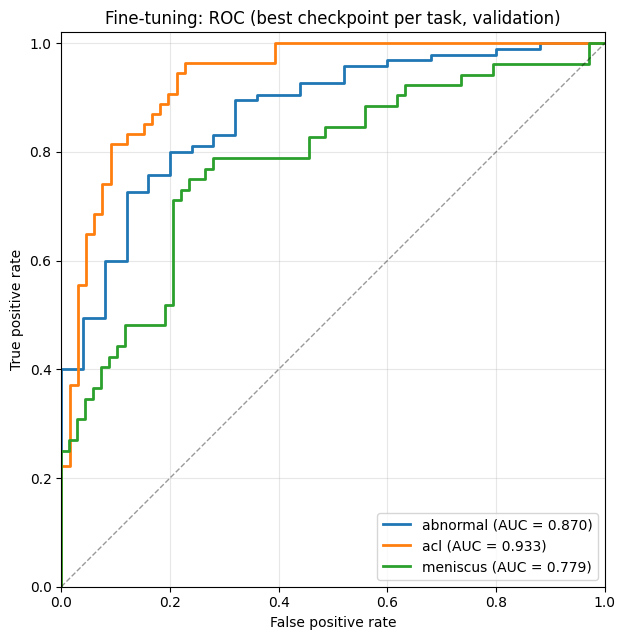

In [49]:
from sklearn.metrics import auc, roc_curve

assert_config_ready()
ensure_checkpoint_dir()
ensure_report_fig_dir()

PLOT_ROC_COMBINED = True
PLOT_ROC_ONE_PER_TASK = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


@torch.no_grad()
def collect_val_probs(model, loader, device):
    """Validation labels and sigmoid probabilities (same as Section 4; defined here so this cell runs standalone)."""
    model.eval()
    logits_list, labels_list = [], []
    for batch in tqdm(loader, desc="Valid", leave=False):
        axial = batch["axial"].to(device)
        coronal = batch["coronal"].to(device)
        sagittal = batch["sagittal"].to(device)
        logit = model(axial=axial, coronal=coronal, sagittal=sagittal)
        logits_list.append(logit.cpu())
        labels_list.append(batch["label"].float().cpu())
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    probs = torch.sigmoid(logits).numpy().ravel()
    return labels.numpy().ravel(), probs


if PLOT_ROC_COMBINED:
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for task in TASKS:
        ck = CHECKPOINT_DIR / f"mrnet_{task}_best.pt"
        if not ck.exists():
            print(f"Skip {task}: no checkpoint {ck.name}")
            continue
        valid_ds = MRNetDataset(
            DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False
        )
        valid_loader = DataLoader(
            valid_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            collate_fn=collate_mrnet,
        )
        model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
        payload = _load_checkpoint(ck)
        state = payload.get("model", payload) if isinstance(payload, dict) else payload
        model.load_state_dict(state, strict=True)
        y_true, y_score = collect_val_probs(model, valid_loader, device)
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            print(f"Skip {task}: only one class in validation labels")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        a = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{task} (AUC = {a:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("Fine-tuning: ROC (best checkpoint per task, validation)")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(
        REPORT_FIG_DIR / "roc_finetune_validation.png",
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

if PLOT_ROC_ONE_PER_TASK:
    for task in TASKS:
        ck = CHECKPOINT_DIR / f"mrnet_{task}_best.pt"
        if not ck.exists():
            print(f"Skip {task}: no checkpoint {ck.name}")
            continue
        valid_ds = MRNetDataset(
            DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False
        )
        valid_loader = DataLoader(
            valid_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            collate_fn=collate_mrnet,
        )
        model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
        payload = _load_checkpoint(ck)
        state = payload.get("model", payload) if isinstance(payload, dict) else payload
        model.load_state_dict(state, strict=True)
        y_true, y_score = collect_val_probs(model, valid_loader, device)
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            print(f"Skip {task}: only one class in validation")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        a = auc(fpr, tpr)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(fpr, tpr, lw=2, color="#1f77b4", label=f"AUC = {a:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(f"Fine-tuning ROC — {task} (validation)")
        ax.legend(loc="lower right")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()


### 5c. Transfer-only — train all three tasks (optional)

Backbone **frozen for every epoch** (head only). Checkpoints: `mrnet_{task}_transfer_only_best.pt`. Metrics: `section5_transfer_only_history.json`.

Set `RUN_TRANSFER_ONLY_THREE_TASKS = True` in the next cell, then use the transfer-only metric and ROC cells below for the same reports as for fine-tuning. Finally run the **head-to-head** cell after both runs exist.


In [ ]:
import json

assert_config_ready()

RUN_TRANSFER_ONLY_THREE_TASKS = False

if RUN_TRANSFER_ONLY_THREE_TASKS:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results_transfer_only = {}
    task_histories_transfer_only = {}
    run_start_to = time.time()
    SECTION5_TRANSFER_ONLY_FILE = CHECKPOINT_DIR / "section5_transfer_only_history.json"

    print(f"[Transfer-only] 3-task run on device='{device}'")
    print(f"Settings: epochs={EPOCHS}, lr={LR}, backbone frozen all epochs")

    for task in TASKS:
        print(f"\n--- [Transfer-only] task: {task} ---")
        train_ds = MRNetDataset(
            DATA_ROOT, "train", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=True
        )
        valid_ds = MRNetDataset(
            DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False
        )
        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            collate_fn=collate_mrnet,
        )
        valid_loader = DataLoader(
            valid_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            collate_fn=collate_mrnet,
        )

        model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
        criterion = nn.BCEWithLogitsLoss()
        model.freeze_backbone()
        optimizer = torch.optim.Adam(
            model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
        )
        best_auc = 0.0
        hist = {
            "train_loss": [],
            "valid_auc": [],
            "valid_bce": [],
            "best_auc": 0.0,
            "best_epoch": -1,
        }

        for epoch in range(EPOCHS):
            tr_loss = train_epoch(
                model, train_loader, criterion, optimizer, device
            )
            _v = validate(model, valid_loader, device)
            va_auc, va_bce = (
                (_v[0], _v[1]) if isinstance(_v, tuple) else (_v, None)
            )
            hist["train_loss"].append(float(tr_loss))
            hist["valid_auc"].append(float(va_auc))
            hist["valid_bce"].append(None if va_bce is None else float(va_bce))
            if (epoch + 1) % 5 == 0 or epoch == 0:
                _vb = f"{va_bce:.4f}" if va_bce is not None else "n/a"
                print(
                    f"  Epoch {epoch + 1:02d}/{EPOCHS:02d} | "
                    f"train_loss={tr_loss:.4f} | valid_auc={va_auc:.4f} | valid_bce={_vb}"
                )
            if va_auc > best_auc:
                best_auc = va_auc
                hist["best_auc"] = float(va_auc)
                hist["best_epoch"] = epoch + 1
                _ckpt = {
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "auc": float(va_auc),
                    "training_mode": "transfer_only",
                }
                if va_bce is not None:
                    _ckpt["valid_bce"] = float(va_bce)
                torch.save(
                    _ckpt,
                    CHECKPOINT_DIR / f"mrnet_{task}_transfer_only_best.pt",
                )

        results_transfer_only[task] = best_auc
        task_histories_transfer_only[task] = hist
        print(f"  Best AUC for {task}: {best_auc:.4f}")

    print("\n=== [Transfer-only] Summary ===")
    for task in TASKS:
        print(f"  {task}: {results_transfer_only[task]:.4f}")
    mean_auc_to = sum(results_transfer_only.values()) / len(TASKS)
    print(f"  Average AUC: {mean_auc_to:.4f}")
    print(
        f"  Elapsed: {(time.time() - run_start_to) / 60:.1f} min"
    )

    rec_to = {
        "training_mode": "transfer_only",
        "config": {
            "EPOCHS": EPOCHS,
            "LR": LR,
            "BATCH_SIZE": BATCH_SIZE,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "NUM_SLICE_SAMPLE": NUM_SLICE_SAMPLE,
            "INPUT_SIZE": INPUT_SIZE,
            "SEED": SEED,
        },
        "summary": {
            "per_task_auc": {k: float(v) for k, v in results_transfer_only.items()},
            "mean_auc": float(mean_auc_to),
            "elapsed_minutes": (time.time() - run_start_to) / 60.0,
        },
        "task_histories": task_histories_transfer_only,
    }
    with open(SECTION5_TRANSFER_ONLY_FILE, "w", encoding="utf-8") as f:
        json.dump(rec_to, f, indent=2)
    print(f"\nSaved metrics to {SECTION5_TRANSFER_ONLY_FILE}")
else:
    print(
        "Skipping transfer-only run (set RUN_TRANSFER_ONLY_THREE_TASKS = True to train)."
    )


[Transfer-only] 3-task run on device='cuda'
Settings: epochs=20, lr=0.0001, backbone frozen all epochs

--- [Transfer-only] task: abnormal ---


  Epoch 01/20 | train_loss=0.5270 | valid_auc=0.4661 | valid_bce=n/a


  Epoch 05/20 | train_loss=0.4819 | valid_auc=0.5284 | valid_bce=n/a


  Epoch 10/20 | train_loss=0.4647 | valid_auc=0.6131 | valid_bce=n/a


  Epoch 15/20 | train_loss=0.4391 | valid_auc=0.6122 | valid_bce=n/a


...

  Epoch 01/20 | train_loss=0.7066 | valid_auc=0.5633 | valid_bce=n/a


  Epoch 05/20 | train_loss=0.6562 | valid_auc=0.6222 | valid_bce=n/a


  Epoch 10/20 | train_loss=0.6287 | valid_auc=0.6083 | valid_bce=n/a


  Epoch 15/20 | train_loss=0.6046 | valid_auc=0.6171 | valid_bce=n/a


  Epoch 20/20 | train_loss=0.5985 | valid_auc=0.6055 | valid_bce=n/a
  Best AUC for meniscus: 0.6292

=== [Transfer-only] Summary ===
  abnormal: 0.6539
  acl: 0.6002
  meniscus: 0.6292
  Average AUC: 0.6278
  Elapsed: 173.4 min

Saved metrics to C:\Users\nickg\dev\CSULB\CECS_553_Project\checkpoints\section5_transfer_only_history.json


### 5d. Transfer-only — load metrics & training curves


Using task_histories_transfer_only from memory (3 tasks)


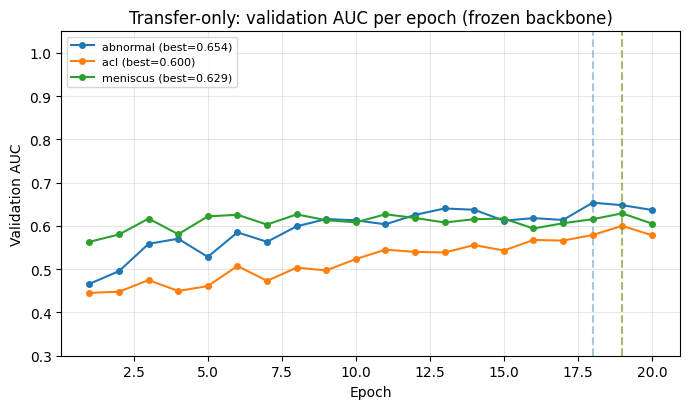

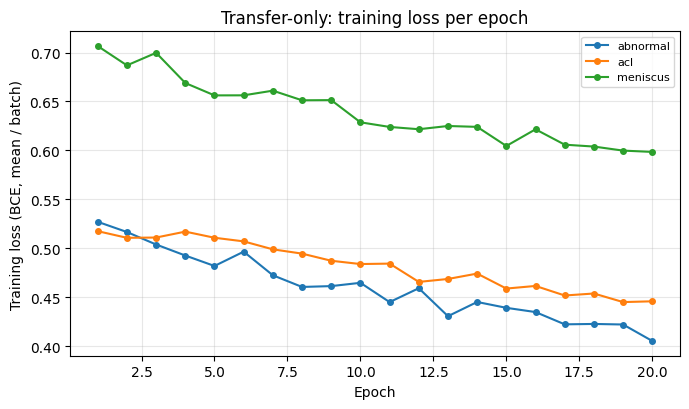

No valid BCE in transfer-only history, or set SHOW_VALID_BCE = False.


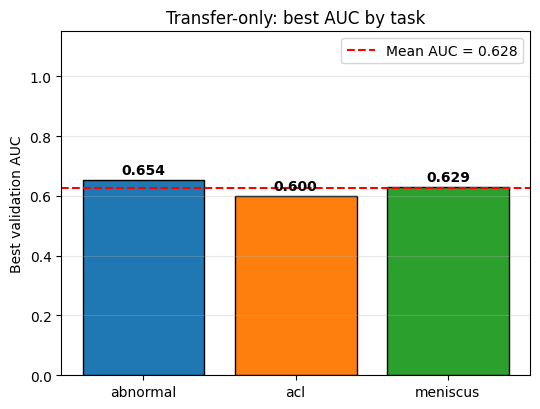


[Transfer-only] Per-task best AUC:
    abnormal: 0.6539  (epoch 18)
         acl: 0.6002  (epoch 19)
    meniscus: 0.6292  (epoch 19)
     Average: 0.6278


In [50]:
import json

assert_config_ready()

_to_path = CHECKPOINT_DIR / "section5_transfer_only_history.json"
if (
    "task_histories_transfer_only" in dir()
    and task_histories_transfer_only
    and len(task_histories_transfer_only) == len(TASKS)
):
    print(f"Using task_histories_transfer_only from memory ({len(task_histories_transfer_only)} tasks)")
elif _to_path.exists():
    with open(_to_path, encoding="utf-8") as f:
        task_histories_transfer_only = json.load(f)["task_histories"]
    print(f"Loaded from {_to_path.name}")
else:
    task_histories_transfer_only = {}
    print(
        f"No transfer-only metrics — run transfer-only training with RUN_TRANSFER_ONLY_THREE_TASKS = True, or add {_to_path.name}"
    )

# Same charts as 5a, for transfer-only (backbone frozen all epochs; no "unfreeze" line)
if not task_histories_transfer_only:
    print("Nothing to plot — run the load cell above and/or transfer-only training first.")
else:
    SHOW_VALID_AUC = True
    SHOW_TRAIN_LOSS = True
    SHOW_VALID_BCE = True
    SHOW_BEST_AUC_BARS = True
    SAVE_REPORT_FIGURES = True  # PNGs for LaTeX report
    hists = task_histories_transfer_only

    colors = {"abnormal": "#1f77b4", "acl": "#ff7f0e", "meniscus": "#2ca02c"}
    _h0 = next(iter(hists.values()))
    _nep = len(_h0["valid_auc"])
    has_vbce = all(
        h.get("valid_bce") and h["valid_bce"] and h["valid_bce"][0] is not None
        for h in hists.values()
    )

    if SHOW_VALID_AUC:
        fig, ax = plt.subplots(figsize=(7, 4.2))
        for t, hist in hists.items():
            ep = np.arange(1, len(hist["valid_auc"]) + 1)
            ax.plot(
                ep, hist["valid_auc"], marker="o", markersize=4,
                label=f'{t} (best={hist["best_auc"]:.3f})', color=colors[t],
            )
            ax.axvline(x=hist["best_epoch"], color=colors[t], linestyle="--", alpha=0.4)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation AUC")
        ax.set_title("Transfer-only: validation AUC per epoch (frozen backbone)")
        ax.legend(fontsize=8)
        ax.set_ylim(0.3, 1.05)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "to_valid_auc.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    if SHOW_TRAIN_LOSS:
        fig, ax = plt.subplots(figsize=(7, 4.2))
        for t, hist in hists.items():
            ep = np.arange(1, len(hist["train_loss"]) + 1)
            ax.plot(ep, hist["train_loss"], marker="o", markersize=4, label=t, color=colors[t])
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Training loss (BCE, mean / batch)")
        ax.set_title("Transfer-only: training loss per epoch")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "to_train_loss.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    if SHOW_VALID_BCE:
        if has_vbce:
            fig, ax = plt.subplots(figsize=(7, 4.2))
            for t, hist in hists.items():
                ep = np.arange(1, len(hist["valid_bce"]) + 1)
                ax.plot(ep, hist["valid_bce"], marker="o", markersize=4, label=t, color=colors[t])
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation BCE (full val set)")
            ax.set_title("Transfer-only: validation BCE per epoch")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            if SAVE_REPORT_FIGURES:
                fig.savefig(
                    REPORT_FIG_DIR / "to_valid_bce.png",
                    dpi=200,
                    bbox_inches="tight",
                    facecolor="white",
                )
            plt.show()
        else:
            print("No valid BCE in transfer-only history, or set SHOW_VALID_BCE = False.")

    tasks_list = list(hists.keys())
    best_aucs = [hists[t]["best_auc"] for t in tasks_list]
    avg_auc = float(np.mean(best_aucs))

    if SHOW_BEST_AUC_BARS:
        fig, ax = plt.subplots(figsize=(5.5, 4.2))
        bars = ax.bar(
            tasks_list, best_aucs, color=[colors[t] for t in tasks_list], edgecolor="black"
        )
        for bar, auc_val in zip(bars, best_aucs):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{auc_val:.3f}", ha="center", va="bottom", fontweight="bold",
            )
        ax.axhline(
            y=avg_auc, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean AUC = {avg_auc:.3f}",
        )
        ax.set_ylabel("Best validation AUC")
        ax.set_title("Transfer-only: best AUC by task")
        ax.set_ylim(0, 1.15)
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        if SAVE_REPORT_FIGURES:
            fig.savefig(
                REPORT_FIG_DIR / "to_best_auc_bars.png",
                dpi=200,
                bbox_inches="tight",
                facecolor="white",
            )
        plt.show()

    print("\n[Transfer-only] Per-task best AUC:")
    for t in tasks_list:
        h = hists[t]
        print(f"  {t:>10s}: {h['best_auc']:.4f}  (epoch {h['best_epoch']})")
    print(f"  {'Average':>10s}: {avg_auc:.4f}")


### 5e. Transfer-only — ROC on validation

Same as 5b, but loads `mrnet_{task}_transfer_only_best.pt` per task.


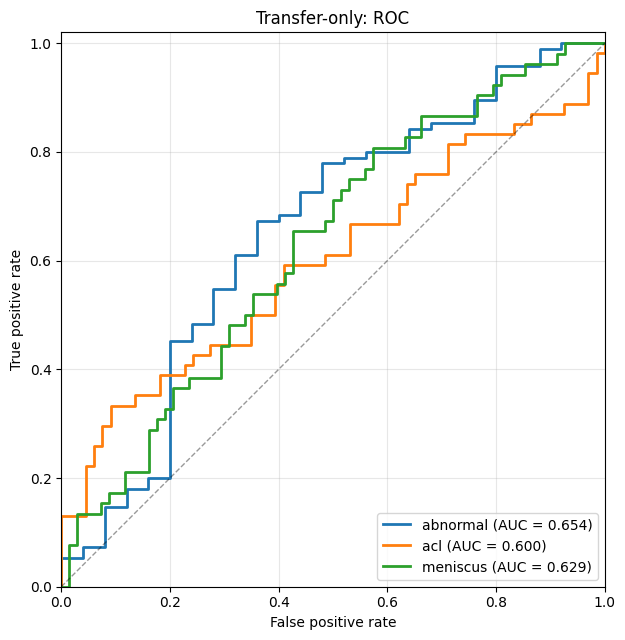

In [51]:
from sklearn.metrics import auc, roc_curve

assert_config_ready()
ensure_checkpoint_dir()
ensure_report_fig_dir()

PLOT_ROC_TRANSFER_COMBINED = True
PLOT_ROC_TRANSFER_ONE_PER_TASK = False
_check_key = "transfer_only"  # checkpoint suffix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

@torch.no_grad()
def collect_val_probs(model, loader, device):
    model.eval()
    logits_list, labels_list = [], []
    for batch in tqdm(loader, desc="Valid", leave=False):
        axial, coronal, sagittal = (
            batch["axial"].to(device),
            batch["coronal"].to(device),
            batch["sagittal"].to(device),
        )
        logit = model(axial=axial, coronal=coronal, sagittal=sagittal)
        logits_list.append(logit.cpu())
        labels_list.append(batch["label"].float().cpu())
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return labels.numpy().ravel(), torch.sigmoid(logits).numpy().ravel()

if PLOT_ROC_TRANSFER_COMBINED:
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for task in TASKS:
        ck = CHECKPOINT_DIR / f"mrnet_{task}_transfer_only_best.pt"
        if not ck.exists():
            print(f"Skip {task}: no {ck.name}")
            continue
        valid_ds = MRNetDataset(
            DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False
        )
        valid_loader = DataLoader(
            valid_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=0, collate_fn=collate_mrnet,
        )
        model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
        payload = _load_checkpoint(ck)
        state = payload.get("model", payload) if isinstance(payload, dict) else payload
        model.load_state_dict(state, strict=True)
        y_true, y_score = collect_val_probs(model, valid_loader, device)
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            print(f"Skip {task}: only one class in validation")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        a = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{task} (AUC = {a:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("Transfer-only: ROC")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(
        REPORT_FIG_DIR / "roc_transfer_only_validation.png",
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

if PLOT_ROC_TRANSFER_ONE_PER_TASK:
    for task in TASKS:
        ck = CHECKPOINT_DIR / f"mrnet_{task}_transfer_only_best.pt"
        if not ck.exists():
            continue
        valid_ds = MRNetDataset(
            DATA_ROOT, "valid", task, INPUT_SIZE, NUM_SLICE_SAMPLE, augment=False
        )
        valid_loader = DataLoader(
            valid_ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=0, collate_fn=collate_mrnet,
        )
        model = MRNet(task=task, pretrained=True, dropout=0.0).to(device)
        payload = _load_checkpoint(ck)
        state = payload.get("model", payload) if isinstance(payload, dict) else payload
        model.load_state_dict(state, strict=True)
        y_true, y_score = collect_val_probs(model, valid_loader, device)
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        a = auc(fpr, tpr)
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.plot(fpr, tpr, lw=2, color="#ff7f0e", label=f"AUC = {a:.3f}")
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title(f"Transfer-only ROC — {task}")
        ax.legend(loc="lower right")
        fig.tight_layout()
        plt.show()


### Head-to-head: fine-tuning vs transfer-only

Compares best validation AUC from `section5_training_history.json` and `section5_transfer_only_history.json`. Run after both training blocks above finish, or with both JSON files present.


Best validation AUC (higher is better)

Task            Fine-tuning  Transfer-only    Delta (FT-TO)
--------------------------------------------------------------
abnormal             0.8699         0.6539          +0.2160
acl                  0.9329         0.6002          +0.3328
meniscus             0.7794         0.6292          +0.1502
--------------------------------------------------------------
mean                 0.8607         0.6278          +0.2330


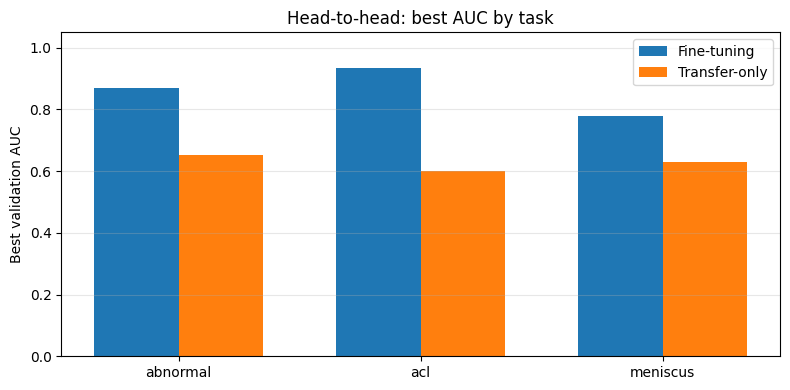

In [52]:
import json

assert_config_ready()
ensure_report_fig_dir()

p_ft = CHECKPOINT_DIR / "section5_training_history.json"
p_to = CHECKPOINT_DIR / "section5_transfer_only_history.json"


def _load_metrics(path):
    if not path.exists():
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def _summary_auc(d):
    if d is None:
        return None, None
    s = d.get("summary", {})
    return s.get("per_task_auc"), s.get("mean_auc")


data_ft = _load_metrics(p_ft)
data_to = _load_metrics(p_to)

if data_ft is None and "results" in dir() and results:
    data_ft = {
        "summary": {
            "per_task_auc": {k: float(v) for k, v in results.items()},
            "mean_auc": float(sum(results.values()) / len(TASKS)),
        }
    }
if data_to is None and "results_transfer_only" in dir() and results_transfer_only:
    data_to = {
        "summary": {
            "per_task_auc": {k: float(v) for k, v in results_transfer_only.items()},
            "mean_auc": float(
                sum(results_transfer_only.values()) / len(TASKS)
            ),
        }
    }

auc_ft, mean_ft = _summary_auc(data_ft)
auc_to, mean_to = _summary_auc(data_to)
if auc_ft and mean_ft is None:
    mean_ft = sum(auc_ft.values()) / len(auc_ft)
if auc_to and mean_to is None:
    mean_to = sum(auc_to.values()) / len(auc_to)

if auc_ft is None or auc_to is None:
    print("Need both runs to compare:")
    if auc_ft is None:
        print(f"  Missing fine-tuning: run training above or add {p_ft.name}")
    if auc_to is None:
        print(
            f"  Missing transfer-only: set RUN_TRANSFER_ONLY_THREE_TASKS = True for transfer-only training or add {p_to.name}"
        )
else:
    print("Best validation AUC (higher is better)\n")
    print(f"{'Task':<12} {'Fine-tuning':>14} {'Transfer-only':>14} {'Delta (FT-TO)':>16}")
    print("-" * 62)
    for t in TASKS:
        a, b = float(auc_ft[t]), float(auc_to[t])
        print(f"{t:<12} {a:14.4f} {b:14.4f} {a - b:+16.4f}")
    print("-" * 62)
    print(
        f"{'mean':<12} {float(mean_ft):14.4f} {float(mean_to):14.4f} {float(mean_ft) - float(mean_to):+16.4f}"
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(TASKS))
    w = 0.35
    ax.bar(
        x - w / 2,
        [auc_ft[t] for t in TASKS],
        w,
        label="Fine-tuning",
        color="#1f77b4",
    )
    ax.bar(
        x + w / 2,
        [auc_to[t] for t in TASKS],
        w,
        label="Transfer-only",
        color="#ff7f0e",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(TASKS)
    ax.set_ylabel("Best validation AUC")
    ax.set_title("Head-to-head: best AUC by task")
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(
        REPORT_FIG_DIR / "head_to_head_best_auc.png",
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()